# BERTopic Pipeline Comparison
This notebook analyzes and compares the results of different BERTopic pipeline outputs using exported metrics and topic information from the `Outputs` directory.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and any other libraries needed for data analysis and visualization.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
display_available = False
try:
    from IPython.display import display
    display_available = True
except ImportError:
    pass

## 2. Load Pipeline Output Tables
Read the relevant files from each BERTopic pipeline output directory for comparison.

In [2]:
# Define paths to topic_info.csv and row_topic_assignments for each BERTopic pipeline
base_dir = 'Code/Outputs'
pipeline_dirs = {
    'Finnhub_BERTopic': 'Finnhub_BERTopic/20260423_232228',
    'GSIB_BERTopic': 'GSIB_BERTopic/20260424_070045',
    'GSIB_BERTopic_FinBert': 'GSIB_BERTopic_FinBert/20260417_031943',
    'GSIB_BERTopic_FinLang': 'GSIB_BERTopic_FinLang/investopedia_embedding/20260423_045921',
}

topic_info = {}
row_assignments = {}
for name, rel_dir in pipeline_dirs.items():
    topic_info_path = os.path.join(base_dir, rel_dir, 'tables', 'topic_info.csv')
    row_assign_path = os.path.join(base_dir, rel_dir, 'row_level', 'row_topic_assignments_all.csv')
    # Fallback for Finnhub_BERTopic which uses train split only
    if not os.path.exists(row_assign_path):
        row_assign_path = os.path.join(base_dir, rel_dir, 'row_level', 'row_topic_assignments_train.csv')
    if os.path.exists(topic_info_path):
        topic_info[name] = pd.read_csv(topic_info_path)
        print(f"Loaded topic_info for {name}")
    else:
        print(f"topic_info.csv not found for {name}")
    if os.path.exists(row_assign_path):
        row_assignments[name] = pd.read_csv(row_assign_path)
        print(f"Loaded row_topic_assignments for {name}")
    else:
        print(f"row_topic_assignments not found for {name}")

Loaded topic_info for Finnhub_BERTopic
Loaded row_topic_assignments for Finnhub_BERTopic
Loaded topic_info for GSIB_BERTopic
Loaded row_topic_assignments for GSIB_BERTopic
Loaded topic_info for GSIB_BERTopic_FinBert
Loaded row_topic_assignments for GSIB_BERTopic_FinBert
Loaded topic_info for GSIB_BERTopic_FinLang
Loaded row_topic_assignments for GSIB_BERTopic_FinLang
Loaded row_topic_assignments for GSIB_BERTopic_FinBert
Loaded topic_info for GSIB_BERTopic_FinLang
Loaded row_topic_assignments for GSIB_BERTopic_FinLang


## 3. Compare Topic Information
Aggregate and compare the number of topics and topic sizes from all BERTopic pipelines.

## 3a. Compare Evaluation Metrics and Optimal Hyperparameters
Load and compare evaluation metrics (from `final_metrics.csv` or `summary_stats.csv`) and optimal hyperparameters (from `best_params_per_fold.csv`) for each BERTopic pipeline.

In [9]:
# Load evaluation metrics and optimal hyperparameters for each pipeline
metrics_files = ['final_metrics.csv', 'summary_stats.csv']
params_file = 'best_params_per_fold.csv'

metrics_data = {}
params_data = {}
for name, rel_dir in pipeline_dirs.items():
    found_metrics = False
    for metrics_file in metrics_files:
        metrics_path = os.path.join(base_dir, rel_dir, 'tables', metrics_file)
        if os.path.exists(metrics_path):
            metrics_data[name] = pd.read_csv(metrics_path)
            print(f"Loaded metrics for {name} from {metrics_file}")
            found_metrics = True
            break
    if not found_metrics:
        print(f"No metrics file found for {name}")
    params_path = os.path.join(base_dir, rel_dir, 'tables', params_file)
    if os.path.exists(params_path):
        params_data[name] = pd.read_csv(params_path)
        print(f"Loaded best params for {name}")
    else:
        print(f"No best_params_per_fold.csv found for {name}")

# Combine metrics into a summary table: one row per pipeline, columns are metric (mean ± std)
summary_rows = []
for name, df in metrics_data.items():
    # Try to handle both wide and long formats
    if 'metric' in df.columns and 'mean' in df.columns:
        # Long format: metric, mean, std
        row = {'Pipeline': name}
        for _, r in df.iterrows():
            metric_name = r['metric'] if 'metric' in r else r['Metric']
            mean = r['mean'] if 'mean' in r else r.get('Mean', None)
            std = r['std'] if 'std' in r else r.get('Std', None)
            if pd.notnull(mean) and pd.notnull(std):
                row[metric_name] = f"{mean:.3f} ± {std:.3f}"
            elif pd.notnull(mean):
                row[metric_name] = f"{mean:.3f}"
        summary_rows.append(row)
    elif 'Metric' in df.columns and 'Mean' in df.columns:
        # Alternative long format
        row = {'Pipeline': name}
        for _, r in df.iterrows():
            metric_name = r['Metric']
            mean = r['Mean']
            std = r['Std'] if 'Std' in r else None
            if pd.notnull(mean) and pd.notnull(std):
                row[metric_name] = f"{mean:.3f} ± {std:.3f}"
            elif pd.notnull(mean):
                row[metric_name] = f"{mean:.3f}"
        summary_rows.append(row)
    else:
        # Wide format: columns are metrics
        row = {'Pipeline': name}
        for col in df.columns:
            if col.lower() in ['pipeline', 'fold', 'run', 'split']: continue
            vals = df[col].dropna()
            if len(vals) > 1:
                row[col] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            elif len(vals) == 1:
                row[col] = f"{vals.iloc[0]:.3f}"
        summary_rows.append(row)

metrics_summary_df = pd.DataFrame(summary_rows)
if display_available:
    display(metrics_summary_df)
else:
    print(metrics_summary_df)

No metrics file found for Finnhub_BERTopic
No best_params_per_fold.csv found for Finnhub_BERTopic
Loaded metrics for GSIB_BERTopic from final_metrics.csv
Loaded best params for GSIB_BERTopic
Loaded metrics for GSIB_BERTopic_FinBert from final_metrics.csv
Loaded best params for GSIB_BERTopic_FinBert
Loaded metrics for GSIB_BERTopic_FinLang from final_metrics.csv
Loaded best params for GSIB_BERTopic_FinLang


,Pipeline,Coherence C_v,Coherence NPMI,Topic Diversity,Intra-topic Similarity,Inter-topic Similarity,Silhouette (cosine),Outlier Ratio,Topic Count
0,GSIB_BERTopic,0.489 ± 0.007,-0.001 ± 0.007,0.809 ± 0.003,0.559 ± 0.004,0.326 ± 0.002,0.079 ± 0.005,0.576 ± 0.004,632.778 ± 5.094
1,GSIB_BERTopic_FinBert,0.520 ± 0.006,0.023 ± 0.005,0.745 ± 0.004,0.843 ± 0.002,0.676 ± 0.006,0.088 ± 0.014,0.719 ± 0.010,479.889 ± 10.228
2,GSIB_BERTopic_FinLang,0.509 ± 0.004,0.007 ± 0.005,0.777 ± 0.004,0.625 ± 0.003,0.303 ± 0.003,0.140 ± 0.004,0.575 ± 0.008,595.667 ± 12.981


In [10]:
# Show best hyperparameter settings per pipeline as a table (if available)
if params_data:
    # Try to extract the best row (e.g., lowest loss or highest score) if multiple rows exist
    best_params_rows = []
    for name, df in params_data.items():
        # If there is a 'mean_score' or 'score' column, take the best row
        if 'mean_score' in df.columns:
            best_row = df.loc[df['mean_score'].idxmax()].copy()
        elif 'score' in df.columns:
            best_row = df.loc[df['score'].idxmax()].copy()
        else:
            best_row = df.iloc[0].copy()
        best_row['Pipeline'] = name
        best_params_rows.append(best_row)
    best_params_df = pd.DataFrame(best_params_rows).set_index('Pipeline')
    if display_available:
        display(best_params_df)
    else:
        print(best_params_df)
else:
    print('No best hyperparameter settings found for any pipeline.')

,fold,n_neighbors,n_components,min_cluster_size,min_samples,ngram_range,cv_val,npmi_val,topic_diversity,intra_topic_similarity,inter_topic_similarity,n_topics,cv_val_norm,npmi_val_norm,topic_diversity_norm,intra_topic_similarity_norm,inter_topic_separation_norm,fold_score
Pipeline,,,,,,,,,,,,,,,,,,
GSIB_BERTopic,1,30,10,20,3,"(1, 2)",0.695306,0.168855,0.862963,0.374695,0.488067,27.0,1.000000,1.000000,0.855540,0.227735,0.718858,0.760426
GSIB_BERTopic_FinBert,1,30,10,10,3,"(1, 2)",0.697899,0.149988,0.775362,0.788120,0.779779,69.0,1.000000,0.801108,0.889583,1.000000,0.476144,0.833367
GSIB_BERTopic_FinLang,1,50,10,10,3,"(1, 2)",0.671777,0.120649,0.825000,0.536749,0.422032,68.0,0.865396,0.634762,1.000000,0.944683,0.052832,0.699535


In [3]:
# Compare number of topics and topic sizes
topic_counts = {name: len(df) for name, df in topic_info.items()}
topic_sizes = {name: df['Count'].describe() if 'Count' in df.columns else None for name, df in topic_info.items()}
print('Number of topics per pipeline:')
print(topic_counts)
print('\nTopic size statistics:')
for name, stats in topic_sizes.items():
    print(f'--- {name} ---')
    print(stats)

Number of topics per pipeline:
{'Finnhub_BERTopic': 52, 'GSIB_BERTopic': 638, 'GSIB_BERTopic_FinBert': 480, 'GSIB_BERTopic_FinLang': 578}

Topic size statistics:
--- Finnhub_BERTopic ---
count     52.000000
mean      37.750000
std       94.253491
min       10.000000
25%       13.750000
50%       21.000000
75%       32.250000
max      696.000000
Name: Count, dtype: float64
--- GSIB_BERTopic ---
count      638.000000
mean       119.862069
std       1170.821437
min         20.000000
25%         27.000000
50%         41.000000
75%         75.750000
max      29503.000000
Name: Count, dtype: float64
--- GSIB_BERTopic_FinBert ---
count      480.000000
mean       159.316667
std       1838.060231
min         20.000000
25%         26.000000
50%         37.500000
75%         60.250000
max      40069.000000
Name: Count, dtype: float64
--- GSIB_BERTopic_FinLang ---
count      578.000000
mean       132.304498
std       1254.105927
min         20.000000
25%         27.000000
50%         44.000000
75%

In [18]:
# Analyze topic_info for the different pipelines: topic size, top words, and topic statistics
topic_info_tables = []
for name, df in topic_info.items():
    df = df.copy()
    df['Pipeline'] = name
    topic_info_tables.append(df)
if topic_info_tables:
    all_topic_info = pd.concat(topic_info_tables, ignore_index=True)
    # Show top 5 topics by size for each pipeline
    for name in all_topic_info['Pipeline'].unique():
        print(f'\nTop 5 topics by size for {name}:')
        top_topics = all_topic_info[all_topic_info['Pipeline'] == name].sort_values('Count', ascending=False).head(5)
        if display_available:
            display(top_topics[['Topic', 'Count', 'Name']]) if 'Name' in top_topics.columns else display(top_topics[['Topic', 'Count']])
        else:
            print(top_topics[['Topic', 'Count', 'Name']] if 'Name' in top_topics.columns else top_topics[['Topic', 'Count']])
    # Show top words for a sample topic in each pipeline
    for name in all_topic_info['Pipeline'].unique():
        print(f'\nSample topic words for {name}:')
        sample_topic = all_topic_info[all_topic_info['Pipeline'] == name].iloc[0]
        if 'Words' in sample_topic:
            print(f"Topic {sample_topic['Topic']}: {sample_topic['Words']}")
        elif 'Top Words' in sample_topic:
            print(f"Topic {sample_topic['Topic']}: {sample_topic['Top Words']}")


Top 5 topics by size for Finnhub_BERTopic:


,Topic,Count,Name
0,-1,696,-1_bank_week_market_2025
1,0,82,0_commentary_fund_q1_international
2,1,58,1_stablecoin_crypto_banks_banco
3,2,57,2_dividend_portfolio_yield_10
4,3,55,3_china_gold_stimulus_pboc



Top 5 topics by size for GSIB_BERTopic:


,Topic,Count,Name
52,-1,29503,-1_says_blackrock_street_bank
53,0,1394,0_ring nasdaq_ring_bell_nasdaq stock
54,1,1353,1_blackstone_deal blackstone_real estate_estate
55,2,923,2_buffett_warren buffett_warren_berkshire
56,3,912,3_brookfield_brookfield asset_asset management...



Top 5 topics by size for GSIB_BERTopic_FinBert:


,Topic,Count,Name
690,-1,40069,-1_says_blackrock_billion_new
691,0,3957,0_oil_fed_rate_falls
692,1,1723,1_stock buy_dividend stock_great_buy
693,2,1202,2_fined_lawsuit_sues_epstein
694,3,653,3_appoints_head_names_hires



Top 5 topics by size for GSIB_BERTopic_FinLang:


,Topic,Count,Name
1170,-1,30056,-1_bank_new_billion_banks
1171,0,1819,0_stocks buy_dividend stocks_stocks_dividend
1172,1,1810,1_epstein_lawsuit_pay_fined
1173,2,935,2_bitcoin_bitcoin etf_spot_spot bitcoin
1174,3,657,3_oil_opec_oil prices_supply



Sample topic words for Finnhub_BERTopic:

Sample topic words for GSIB_BERTopic:

Sample topic words for GSIB_BERTopic_FinBert:

Sample topic words for GSIB_BERTopic_FinLang:


## 4. Visualize Topic Counts and Sizes
Create bar plots to compare the number of topics and topic size distributions across BERTopic pipelines.

C:\Users\gianf\AppData\Local\Temp\ipykernel_23216\3666769435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(topic_counts.keys()), y=list(topic_counts.values()), palette='Blues_d')


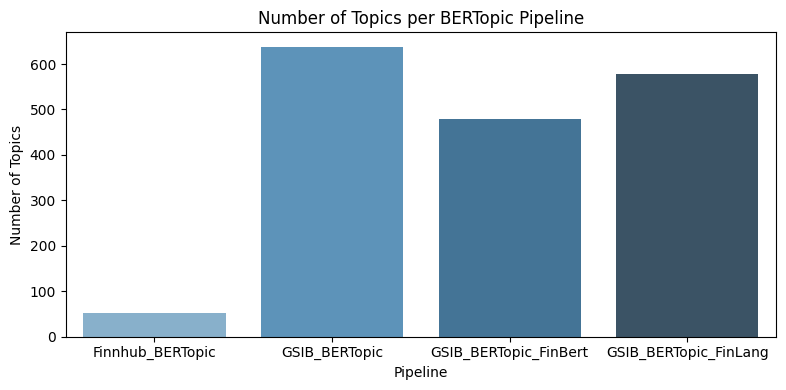

C:\Users\gianf\AppData\Local\Temp\ipykernel_23216\3666769435.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pipeline', y='Topic Size', data=sizes_df, palette='Greens_d')


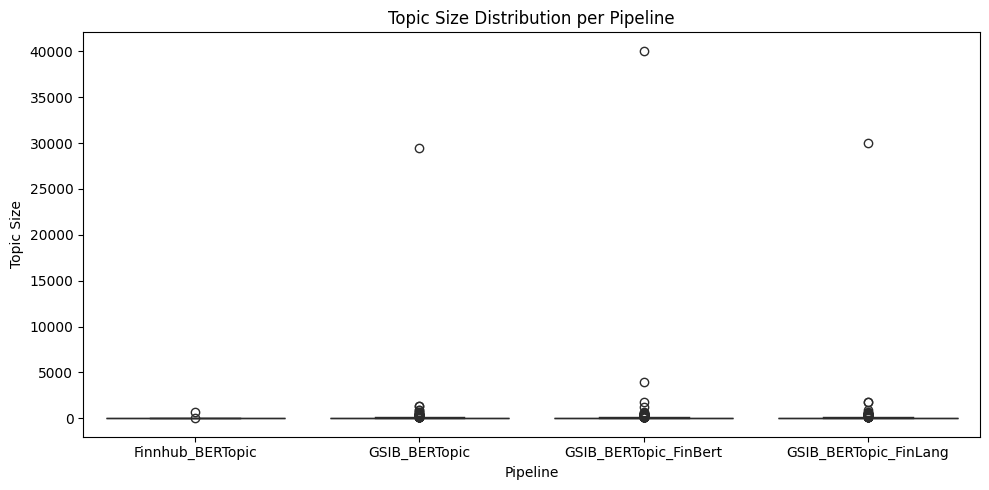

In [4]:
# Bar plot for number of topics
plt.figure(figsize=(8, 4))
sns.barplot(x=list(topic_counts.keys()), y=list(topic_counts.values()), palette='Blues_d')
plt.title('Number of Topics per BERTopic Pipeline')
plt.ylabel('Number of Topics')
plt.xlabel('Pipeline')
plt.tight_layout()
plt.show()

# Boxplot for topic sizes (if available)
plt.figure(figsize=(10, 5))
sizes_data = []
for name, df in topic_info.items():
    if 'Count' in df.columns:
        for val in df['Count']:
            sizes_data.append({'Pipeline': name, 'Topic Size': val})
if sizes_data:
    sizes_df = pd.DataFrame(sizes_data)
    sns.boxplot(x='Pipeline', y='Topic Size', data=sizes_df, palette='Greens_d')
    plt.title('Topic Size Distribution per Pipeline')
    plt.tight_layout()
    plt.show()